# Assignment 4 Student Notebook: Skin-Lesion Segmentation

Complete the TODO cells and run the required experiments.

Download the Dataset

In [37]:
# !pip install gdown
# !gdown 1fOFVivt3jxjqjdvZtHme6Nqcw1MpWUI_

In [38]:
# !unzip Dataset.zip
# !rm Dataset/Images/LICENSE.txt

## 1. Overview

This notebook trains the required segmentation models, reports the metrics, and saves prediction examples.

## 2. Imports

In [39]:
# Standard imports
import os
import random
from pathlib import Path
from dataclasses import dataclass
from typing import List, Tuple, Optional

import numpy as np
import pandas as pd
from PIL import Image
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

In [40]:
TORCHVISION_AVAILABLE = True
try:
    from torchvision import transforms
    from torchvision.models import resnet50, ResNet50_Weights
except Exception as e:
    TORCHVISION_AVAILABLE = False
    print("torchvision is not available or failed to import.")
    print("The notebook will use fallback transforms and a fallback encoder.")
    print("Import error:", e)

## 3. Configuration

Edit the settings below as needed.

In [41]:
@dataclass
class Config:
    dataset_dir: str = "./Dataset"
    image_dir: str = "Images"
    mask_dir: str = "Masks"
    image_size: int = 256
    batch_size: int = 16
    # num_workers: int = 0  # set to 0 if running on CPU
    num_workers: int = 8  # set to 0 if running on CPU
    lr: float = 1e-4
    epochs: int = 10
    threshold: float = 0.5
    seed: int = 42
    train_ratio: float = 0.70
    val_ratio: float = 0.15
    test_ratio: float = 0.15
    output_dir: str = "./outputs"
    num_visualizations: int = 4

cfg = Config()
MODEL_VARIANTS = ["unet_scratch", "resunet_frozen", "resunet_finetune"]
LOSS_COMPARISON_MODEL = "resunet_finetune"

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)
print(cfg)

Device: cuda
Config(dataset_dir='./Dataset', image_dir='Images', mask_dir='Masks', image_size=256, batch_size=16, num_workers=8, lr=0.0001, epochs=10, threshold=0.5, seed=42, train_ratio=0.7, val_ratio=0.15, test_ratio=0.15, output_dir='./outputs', num_visualizations=4)


In [42]:
from google.colab import drive
drive.mount('/content/drive')
cfg.dataset_dir = "/content/drive/MyDrive/CS 489/as4/Dataset"
cfg.output_dir  = "/content/drive/MyDrive/CS 489/as4/outputs"

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## 4. Reproducibility

In [43]:
def set_seed(seed: int = 42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

set_seed(cfg.seed)

## 5. Dataset paths

In [44]:
if TORCHVISION_AVAILABLE:
    image_transform = transforms.Compose([
        transforms.Resize((cfg.image_size, cfg.image_size)),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406],
                             std=[0.229, 0.224, 0.225]),
    ])

    mask_transform = transforms.Compose([
        transforms.Resize((cfg.image_size, cfg.image_size), interpolation=transforms.InterpolationMode.NEAREST),
        transforms.PILToTensor(),
    ])
else:
    image_transform = None
    mask_transform = None

def simple_image_to_tensor(img: Image.Image) -> torch.Tensor:
    img = img.resize((cfg.image_size, cfg.image_size))
    arr = np.array(img).astype(np.float32) / 255.0
    if arr.ndim == 2:
        arr = np.stack([arr, arr, arr], axis=-1)
    arr = arr.transpose(2, 0, 1)
    tensor = torch.from_numpy(arr)
    mean = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
    std = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)
    tensor = (tensor - mean) / std
    return tensor

def simple_mask_to_tensor(mask: Image.Image) -> torch.Tensor:
    mask = mask.resize((cfg.image_size, cfg.image_size))
    arr = np.array(mask)
    if arr.ndim == 3:
        arr = arr[..., 0]
    arr = (arr > 127).astype(np.float32)
    return torch.from_numpy(arr).unsqueeze(0)

## 6. Transforms

In [45]:
class SegmentationDataset(Dataset):
    def __init__(self, file_names: List[str], image_root: Path, mask_root: Path):
        self.file_names = file_names
        self.image_root = image_root
        self.mask_root = mask_root

    def __len__(self):
        return len(self.file_names)

    def __getitem__(self, idx):
        name = self.file_names[idx]
        image_path = self.image_root / f"{name}.jpg"
        mask_path = self.mask_root / f"{name}_segmentation.png"

        image = Image.open(image_path).convert("RGB")
        mask = Image.open(mask_path).convert("L")

        if TORCHVISION_AVAILABLE:
            image = image_transform(image)
            mask = mask_transform(mask).float() / 255.0
            mask = (mask > 0.5).float()
        else:
            image = simple_image_to_tensor(image)
            mask = simple_mask_to_tensor(mask)

        return image, mask, name

## 7. Dataset class

In [46]:
def collect_file_names(dataset_dir: str, image_dir: str, mask_dir: str) -> Tuple[List[str], Path, Path]:
    image_root = Path(dataset_dir) / image_dir
    mask_root = Path(dataset_dir) / mask_dir

    if not image_root.exists():
        raise FileNotFoundError(f"Image folder not found: {image_root}")
    if not mask_root.exists():
        raise FileNotFoundError(f"Mask folder not found: {mask_root}")

    case_names = sorted([p.stem for p in image_root.iterdir() if p.is_file()])

    return case_names, image_root, mask_root

def split_file_names(file_names: List[str], seed: int, train_ratio: float, val_ratio: float, test_ratio: float):
    assert abs(train_ratio + val_ratio + test_ratio - 1.0) < 1e-6, "Ratios must sum to 1."

    rng = random.Random(seed)
    names = file_names.copy()
    rng.shuffle(names)

    n = len(names)
    n_train = int(n * train_ratio)
    n_val = int(n * val_ratio)
    n_test = n - n_train - n_val

    train_names = names[:n_train]
    val_names = names[n_train:n_train+n_val]
    test_names = names[n_train+n_val:]

    return train_names, val_names, test_names

file_names, image_root, mask_root = collect_file_names(cfg.dataset_dir, cfg.image_dir, cfg.mask_dir)
train_names, val_names, test_names = split_file_names(
    file_names, cfg.seed, cfg.train_ratio, cfg.val_ratio, cfg.test_ratio
)

print("Total samples:", len(file_names))
print("Train:", len(train_names), "Val:", len(val_names), "Test:", len(test_names))

Total samples: 1000
Train: 700 Val: 150 Test: 150


## 8. Split and loaders

In [47]:
train_dataset = SegmentationDataset(train_names, image_root, mask_root)
val_dataset = SegmentationDataset(val_names, image_root, mask_root)
test_dataset = SegmentationDataset(test_names, image_root, mask_root)

train_loader = DataLoader(train_dataset, batch_size=cfg.batch_size, shuffle=True, num_workers=cfg.num_workers)
val_loader = DataLoader(val_dataset, batch_size=cfg.batch_size, shuffle=False, num_workers=cfg.num_workers)
test_loader = DataLoader(test_dataset, batch_size=cfg.batch_size, shuffle=False, num_workers=cfg.num_workers)

cfg.train_loader = train_loader
cfg.val_loader = val_loader
cfg.test_loader = test_loader

## 9. Sample visualization

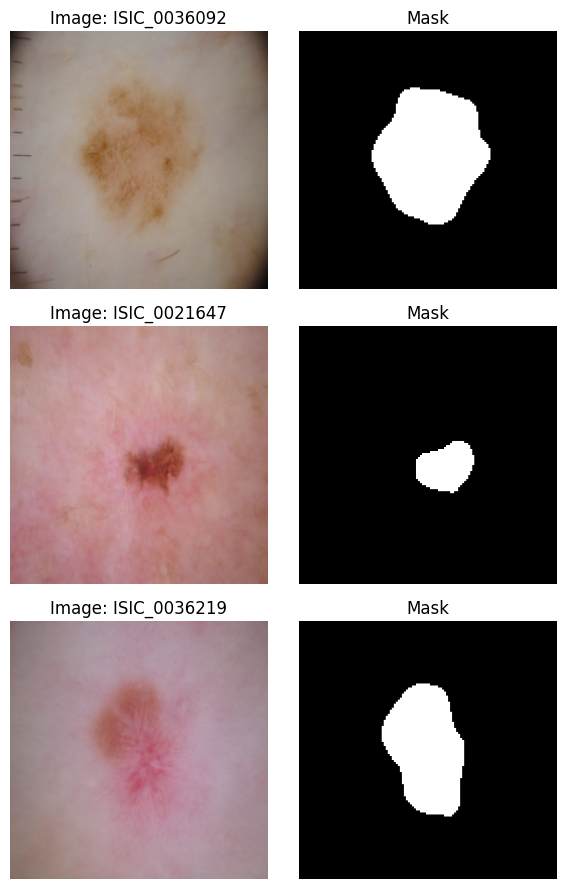

In [48]:
def denormalize_image(x: torch.Tensor) -> np.ndarray:
    x = x.detach().cpu().clone()
    mean = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
    std = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)
    x = x * std + mean
    x = x.clamp(0, 1)
    return x.permute(1, 2, 0).numpy()

def show_dataset_samples(dataset, n=3):
    fig, axes = plt.subplots(n, 2, figsize=(6, 3*n))
    if n == 1:
        axes = np.array([axes])

    for i in range(n):
        image, mask, name = dataset[i]
        axes[i, 0].imshow(denormalize_image(image))
        axes[i, 0].set_title(f"Image: {name}")
        axes[i, 0].axis("off")

        axes[i, 1].imshow(mask.squeeze().numpy(), cmap="gray")
        axes[i, 1].set_title("Mask")
        axes[i, 1].axis("off")

    plt.tight_layout()
    plt.show()

show_dataset_samples(train_dataset, n=min(3, len(train_dataset)))

## 10. Metrics

Complete the metric functions for binary segmentation.

In [49]:
def confusion_matrix_from_masks(y_true: torch.Tensor, y_pred: torch.Tensor):
    # FINISHED:
    # 1. Flatten the tensors.
    y_true_flatten = torch.flatten(y_true, start_dim = 0, end_dim = -1)
    y_pred_flatten = torch.flatten(y_pred, start_dim = 0, end_dim = -1)

    # 2. Count TN, FP, FN, TP.
    tn = fp = fn = tp = 0
    tp = ((y_true == 1) & (y_pred == 1)).sum().item()
    tn = ((y_true == 0) & (y_pred == 0)).sum().item()
    fp = ((y_true == 0) & (y_pred == 1)).sum().item()
    fn = ((y_true == 1) & (y_pred == 0)).sum().item()

    # 3. Return them in the order: tn, fp, fn, tp.
    return tn, fp, fn, tp


def calculate_metrics(y_true: torch.Tensor, y_pred: torch.Tensor):

    # FINISHED:
    # Use the confusion counts to compute:
    # ACC, Dice, IoU, FPR, FNR

    tn, fp, fn, tp = confusion_matrix_from_masks(y_true, y_pred)
    epsilon = 1e-9

    ACC  = (tp + tn) / (tp + tn + fp + fn + epsilon)
    dice = (2 * tp ) / (2 * tp + fp + fn + epsilon)
    iou  = (tp) / (tp + fp + fn + epsilon)
    fpr  = (fp) / (fp + tn + epsilon)
    fnr  = (fn) / (fn + tp + epsilon)

    return ACC, dice, iou, fpr, fnr




## 11. Losses

Complete Dice loss and Dice+BCE loss.

In [50]:
class DiceLoss(nn.Module):
    def __init__(self, smooth: float = 1e-6):
        super().__init__()
        self.smooth = smooth

    def forward(self, logits: torch.Tensor, targets: torch.Tensor):
        # TODO:
        # 1. Convert logits to probabilities with sigmoid.
        preds = torch.sigmoid(logits)

        # 2. Flatten predictions and targets.
        preds_flatten = torch.flatten(preds, start_dim = 0, end_dim = -1)
        targets_flatten = torch.flatten(targets, start_dim = 0, end_dim = -1)

        # 3. Compute Dice loss.
        preds_sum = preds_flatten.sum()
        targets_sum = targets_flatten.sum()
        preds_targets_sum = (preds_flatten * targets_flatten).sum()

        dice_loss = 1 - ((2 * preds_targets_sum + self.smooth) / (preds_sum + targets_sum + self.smooth))

        return dice_loss


class DiceBCELoss(nn.Module):
    def __init__(self, smooth: float = 1e-6):
        super().__init__()
        self.dice = DiceLoss(smooth=smooth)
        self.bce = nn.BCEWithLogitsLoss()

    def forward(self, logits: torch.Tensor, targets: torch.Tensor):
        # FINISHED:
        # Return Dice loss + BCE loss.
        return self.dice(logits, targets) + self.bce(logits, targets)


def build_criterion(loss_name: str):
    # FINISHED:
    # Return DiceLoss() for "dice"
    # Return DiceBCELoss() for "dice_bce"
    if loss_name == "dice":
        return DiceLoss()
    elif loss_name == "dice_bce":
        return DiceBCELoss()
    else:
        raise Exception(f"Unknown loss: {loss_name}")

## 12. Decoder blocks

In [51]:
class ConvBlock(nn.Module):
    def __init__(self, in_channels, out_channels):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),
        )

    def forward(self, x):
        return self.block(x)

class DecoderBlock(nn.Module):
    def __init__(self, in_channels, skip_channels, out_channels):
        super().__init__()
        self.up = nn.ConvTranspose2d(in_channels, in_channels // 2, kernel_size=2, stride=2)
        self.conv = ConvBlock(in_channels // 2 + skip_channels, out_channels)

    def forward(self, x, skip):
        x = self.up(x)
        if x.shape[-2:] != skip.shape[-2:]:
            x = F.interpolate(x, size=skip.shape[-2:], mode="bilinear", align_corners=False)
        x = torch.cat([x, skip], dim=1)
        return self.conv(x)

## 13. U-Net

Complete the baseline model.

In [52]:
class UNetScratch(nn.Module):
    def __init__(self, in_channels=3, out_channels=1):
        super().__init__()
        self.enc1 = ConvBlock(in_channels, 64)
        self.pool1 = nn.MaxPool2d(2)

        self.enc2 = ConvBlock(64, 128)
        self.pool2 = nn.MaxPool2d(2)

        self.enc3 = ConvBlock(128, 256)
        self.pool3 = nn.MaxPool2d(2)

        self.enc4 = ConvBlock(256, 512)
        self.pool4 = nn.MaxPool2d(2)

        self.bottleneck = ConvBlock(512, 1024)

        self.dec4 = DecoderBlock(1024, 512, 512)
        self.dec3 = DecoderBlock(512, 256, 256)
        self.dec2 = DecoderBlock(256, 128, 128)
        self.dec1 = DecoderBlock(128, 64, 64)

        self.out_conv = nn.Conv2d(64, out_channels, kernel_size=1)

    def forward(self, x):

        # FINISHED:
        # Run the encoder, bottleneck, decoder, and final output layer.

        # Encoder:
        e1 = self.enc1(x)
        e2 = self.enc2(self.pool1(e1))
        e3 = self.enc3(self.pool2(e2))
        e4 = self.enc4(self.pool3(e3))

        # Bottleneck:
        b = self.bottleneck(self.pool4(e4))

        # Decoder:
        d4 = self.dec4(b,  e4)
        d3 = self.dec3(d4, e3)
        d2 = self.dec2(d3, e2)
        d1 = self.dec1(d2, e1)

        return self.out_conv(d1)

## 14. Encoder

In [53]:
class FallbackEncoder(nn.Module):
    def __init__(self):
        super().__init__()
        self.layer0 = nn.Sequential(
            nn.Conv2d(3, 64, 7, stride=2, padding=3, bias=False),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
        )
        self.pool = nn.MaxPool2d(2)
        self.layer1 = ConvBlock(64, 128)
        self.layer2 = ConvBlock(128, 256)
        self.layer3 = ConvBlock(256, 512)
        self.layer4 = ConvBlock(512, 1024)

    def forward(self, x):
        x0 = self.layer0(x)                   # 1/2
        x1 = self.layer1(self.pool(x0))       # 1/4
        x2 = self.layer2(F.max_pool2d(x1, 2)) # 1/8
        x3 = self.layer3(F.max_pool2d(x2, 2)) # 1/16
        x4 = self.layer4(F.max_pool2d(x3, 2)) # 1/32
        return x0, x1, x2, x3, x4

class ResNetEncoder(nn.Module):
    def __init__(self, pretrained=True):
        super().__init__()
        self.using_torchvision = TORCHVISION_AVAILABLE
        if TORCHVISION_AVAILABLE:
            weights = ResNet50_Weights.DEFAULT if pretrained else None
            backbone = resnet50(weights=weights)
            self.layer0 = nn.Sequential(backbone.conv1, backbone.bn1, backbone.relu)   # 1/2
            self.pool = backbone.maxpool                                               # 1/4 after pooling
            self.layer1 = backbone.layer1
            self.layer2 = backbone.layer2
            self.layer3 = backbone.layer3
            self.layer4 = backbone.layer4
        else:
            self.fallback = FallbackEncoder()

    def forward(self, x):
        if self.using_torchvision:
            x0 = self.layer0(x)          # 64 channels
            x1 = self.layer1(self.pool(x0))
            x2 = self.layer2(x1)
            x3 = self.layer3(x2)
            x4 = self.layer4(x3)
            return x0, x1, x2, x3, x4
        else:
            return self.fallback(x)

## 15. ResUNet

Complete the pretrained model.

In [54]:
class ResUNet(nn.Module):
    def __init__(self, pretrained=True):
        super().__init__()
        self.encoder = ResNetEncoder(pretrained=pretrained)

        if TORCHVISION_AVAILABLE:
            ch0, ch1, ch2, ch3, ch4 = 64, 256, 512, 1024, 2048
        else:
            ch0, ch1, ch2, ch3, ch4 = 64, 128, 256, 512, 1024

        self.center = ConvBlock(ch4, ch4)

        self.dec4 = DecoderBlock(ch4, ch3, 512)
        self.dec3 = DecoderBlock(512, ch2, 256)
        self.dec2 = DecoderBlock(256, ch1, 128)
        self.dec1 = DecoderBlock(128, ch0, 64)

        self.out_conv = nn.Conv2d(64, 1, kernel_size=1)

    def forward(self, x):
        # FINISHED:
        # 1. Get encoder feature maps.
        e0, e1, e2, e3, e4 = self.encoder(x)

        # 2. Run the center block and decoder blocks.
        c  = self.center(e4)
        d4 = self.dec4(c,  e3)
        d3 = self.dec3(d4, e2)
        d2 = self.dec2(d3, e1)
        d1 = self.dec1(d2, e0)

        # 3. Produce the final 1-channel logit map.
        logits = self.out_conv(d1)

        # 4. Resize to the input spatial size if needed.
        logits = F.interpolate(logits, size = x.shape[-2:], mode = "bilinear", align_corners = False)
        return logits

## 16. Model factory

Build the required model variants.

In [55]:
def freeze_batchnorm(module: nn.Module):
    # You may keep this helper as given.
    for m in module.modules():
        if isinstance(m, nn.BatchNorm2d):
            m.eval()
            for p in m.parameters():
                p.requires_grad = False


def build_model(model_name: str):
    # FINISHED:
    # - "unet_scratch": build U-Net from scratch
    # - "resunet_frozen": build ResUNet and freeze the encoder
    # - "resunet_finetune": build ResUNet and train all layers
    if model_name == "unet_scratch":
        return UNetScratch()

    elif model_name == "resunet_frozen":
        model = ResUNet(pretrained=True)
        for p in model.encoder.parameters():
            p.requires_grad = False
        freeze_batchnorm(model.encoder)
        return model

    elif model_name == "resunet_finetune":
        return ResUNet(pretrained=True)

    else:
        raise Exception("Error with build_model.")

## 17. Train and evaluate

Complete the training and evaluation loops.

In [56]:
def train_one_epoch(model, loader, criterion, optimizer):

    # FINISHED:
    # Run one training epoch and return the average training loss.

    model.train()
    total_loss = 0.0

    for images, masks, _ in loader:
        images, masks = images.to(device), masks.to(device)
        optimizer.zero_grad()
        logits = model(images)
        loss = criterion(logits, masks)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()

    avg_loss = total_loss / len(loader)
    return avg_loss



@torch.no_grad()
def evaluate(model, loader, criterion, threshold=0.5):

    # FINISHED:
    # Evaluate the model and return:
    # average loss, average metrics dictionary

    model.eval()
    total_loss = total_acc = total_dice = total_iou = total_fpr = total_fnr = 0.0

    for images, masks, _ in loader:
        images, masks = images.to(device), masks.to(device)
        logits = model(images)
        loss = criterion(logits, masks)
        total_loss += loss.item()

        preds = (torch.sigmoid(logits) >= threshold).float()
        acc, dice, iou, fpr, fnr = calculate_metrics(masks, preds)
        total_acc  += acc
        total_dice += dice
        total_iou  += iou
        total_fpr  += fpr
        total_fnr  += fnr

    length = len(loader)
    avg_loss = total_loss / length
    avg_metrics = {
        "acc":  total_acc  / length,
        "dice": total_dice / length,
        "iou":  total_iou  / length,
        "fpr":  total_fpr  / length,
        "fnr":  total_fnr  / length,
    }

    return avg_loss, avg_metrics

## 18. Train one experiment

Train one model-loss experiment and return the test metrics.

In [57]:
def train_model(model_name: str, loss_name: str, cfg: Config):

    # FINISHED:
    # 1. Build the model and loss.
    model = build_model(model_name)
    model = model.to(device)
    criterion = build_criterion(loss_name)

    # 2. Create the optimizer.
    optimizer = torch.optim.Adam(model.parameters(), lr=cfg.lr)

    # 3. Train for cfg.epochs.
    history = []
    best_dice = -1.0
    ckpt_path = f"{model_name}_{loss_name}_best.pth"

    for epoch in range(cfg.epochs):
        train_loss = train_one_epoch(model, cfg.train_loader, criterion, optimizer)
        val_loss, val_metrics = evaluate(model, cfg.val_loader, criterion)
        history.append({"epoch": epoch + 1, "train_loss": train_loss, "val_loss": val_loss, **val_metrics})

        # 4. Save the best checkpoint using validation Dice.
        if val_metrics["dice"] > best_dice:
            best_dice = val_metrics["dice"]
            print(f"  - Epoch {epoch}: New best dice: {best_dice}")
            torch.save(model.state_dict(), ckpt_path)

    # 5. Evaluate on the test set.
    model.load_state_dict(torch.load(ckpt_path, weights_only = True))
    test_loss, test_metrics = evaluate(model, cfg.test_loader, criterion)

    # 6. Return model, history_df, metrics_row.
    history_df = pd.DataFrame(history)
    metrics_row = {"model": model_name, "loss": loss_name, "test_loss": test_loss, **test_metrics}
    return model, history_df, metrics_row

## 19. Save predictions

In [58]:
@torch.no_grad()
def save_predictions(model, loader, save_dir: str, threshold: float = 0.5, max_items: int = 4):
    save_dir = Path(save_dir)
    save_dir.mkdir(parents=True, exist_ok=True)

    model.eval()
    saved = 0

    for images, masks, names in loader:
        images = images.to(device)
        masks = masks.to(device)

        logits = model(images)
        probs = torch.sigmoid(logits)
        preds = (probs >= threshold).float()

        for i in range(images.size(0)):
            if saved >= max_items:
                return

            image_np = denormalize_image(images[i].cpu())
            mask_np = masks[i].squeeze().cpu().numpy()
            pred_np = preds[i].squeeze().cpu().numpy()

            fig, axes = plt.subplots(1, 3, figsize=(9, 3))
            axes[0].imshow(image_np)
            axes[0].set_title("Image")
            axes[0].axis("off")

            axes[1].imshow(mask_np, cmap="gray")
            axes[1].set_title("Ground Truth")
            axes[1].axis("off")

            axes[2].imshow(pred_np, cmap="gray")
            axes[2].set_title("Prediction")
            axes[2].axis("off")

            plt.tight_layout()
            out_path = save_dir / f"{Path(names[i]).stem}_comparison.png"
            plt.savefig(out_path, bbox_inches="tight")
            plt.close(fig)

            saved += 1

## 20. Run assignment experiments

Run the required experiments for Table 1 and Table 2.

In [59]:

Path(cfg.output_dir).mkdir(parents=True, exist_ok=True)

# FINISHED:
# Run these experiments:
# 1. unet_scratch + dice
# 2. resunet_frozen + dice
# 3. resunet_finetune + dice
# 4. resunet_finetune + dice_bce
#
# Suggested outputs:
# - all_results
# - all_histories
# - trained_models
# - loss_results
# - loss_histories

experiments = [
    ("unet_scratch",     "dice"),
    ("resunet_frozen",   "dice"),
    ("resunet_finetune", "dice"),
    ("resunet_finetune", "dice_bce"),
]

all_results   = []
all_histories = {}
trained_models = {}

for model_name, loss_name in experiments:
    print(f"Beginning Experiment {model_name}, {loss_name}.")
    key = f"{model_name}_{loss_name}"
    model, history_df, metrics_row = train_model(model_name, loss_name, cfg)
    save_predictions(model, cfg.test_loader,
                     save_dir  = f"{cfg.output_dir}/{key}/predictions",
                     threshold = cfg.threshold,
                     max_items = cfg.num_visualizations)
    all_results.append(metrics_row)
    all_histories[key]  = history_df
    trained_models[key] = model
    print(f"FInished Experiment {model_name}, {loss_name}.")


all_results    = pd.DataFrame(all_results)
loss_results   = all_results.iloc[2:]
loss_histories = {k: all_histories[k] for k in list(all_histories)[-2:]}


Beginning Experiment unet_scratch, dice.
  - Epoch 0: New best dice: 0.6856628706818403
  - Epoch 1: New best dice: 0.7338033316066703
  - Epoch 2: New best dice: 0.7350924341429551
  - Epoch 3: New best dice: 0.7933310975364255
  - Epoch 4: New best dice: 0.7988029859051082
  - Epoch 5: New best dice: 0.8093502314830939
  - Epoch 6: New best dice: 0.8228348932452054
FInished Experiment unet_scratch, dice.
Beginning Experiment resunet_frozen, dice.
Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /root/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 280MB/s]


  - Epoch 0: New best dice: 0.7261172644568796
  - Epoch 1: New best dice: 0.7439528111425922
  - Epoch 2: New best dice: 0.8544778058612426
  - Epoch 4: New best dice: 0.8553560662514318
  - Epoch 5: New best dice: 0.8665760150020875
  - Epoch 6: New best dice: 0.8687808239836305
  - Epoch 8: New best dice: 0.8737270503528286
FInished Experiment resunet_frozen, dice.
Beginning Experiment resunet_finetune, dice.
  - Epoch 0: New best dice: 0.794877686119028
  - Epoch 1: New best dice: 0.8581658042718716
  - Epoch 2: New best dice: 0.8741525750222617
  - Epoch 3: New best dice: 0.884213677992905
  - Epoch 5: New best dice: 0.8880777976002181
  - Epoch 7: New best dice: 0.890226114160863
FInished Experiment resunet_finetune, dice.
Beginning Experiment resunet_finetune, dice_bce.
  - Epoch 0: New best dice: 0.7829278962240972
  - Epoch 1: New best dice: 0.8683053674266107
  - Epoch 2: New best dice: 0.8719020408556191
  - Epoch 3: New best dice: 0.8772039582675191
  - Epoch 4: New best di

## 21. Table 1: model comparison

In [61]:
model_results_df = pd.DataFrame(all_results)
table1_df = model_results_df[["model", "acc", "dice", "iou", "fpr", "fnr", "test_loss"]]
table1_df

,model,acc,dice,iou,fpr,fnr,test_loss
0,unet_scratch,0.905390,0.833936,0.716113,0.074903,0.140210,0.257378
1,resunet_frozen,0.921973,0.863303,0.760462,0.063004,0.115566,0.220632
2,resunet_finetune,0.943071,0.895418,0.811822,0.033756,0.114011,0.184071
3,resunet_finetune,0.937777,0.889473,0.802142,0.046288,0.100346,0.382783


## 22. Save tables

This saves both required result tables.

In [62]:
loss_results_df = pd.DataFrame(loss_results)
table2_df = loss_results_df[["loss", "acc", "dice", "iou", "fpr", "fnr", "test_loss"]]
display(table2_df)

table1_path = Path(cfg.output_dir) / "table1_model_comparison.csv"
table2_path = Path(cfg.output_dir) / "table2_loss_comparison.csv"

table1_df.to_csv(table1_path, index=False)
table2_df.to_csv(table2_path, index=False)

print("Saved:", table1_path)
print("Saved:", table2_path)

,loss,acc,dice,iou,fpr,fnr,test_loss
2,dice,0.943071,0.895418,0.811822,0.033756,0.114011,0.184071
3,dice_bce,0.937777,0.889473,0.802142,0.046288,0.100346,0.382783


Saved: /content/drive/MyDrive/CS 489/as4/outputs/table1_model_comparison.csv
Saved: /content/drive/MyDrive/CS 489/as4/outputs/table2_loss_comparison.csv


## 23. Plot curves

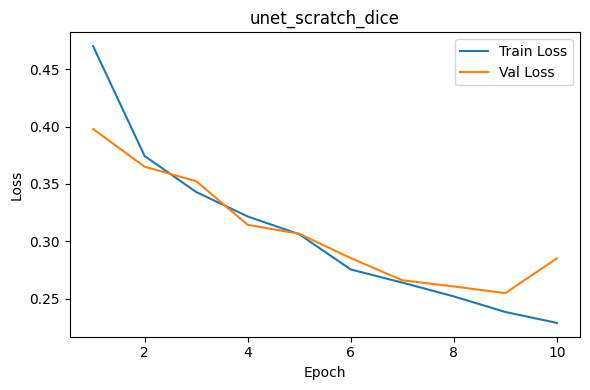

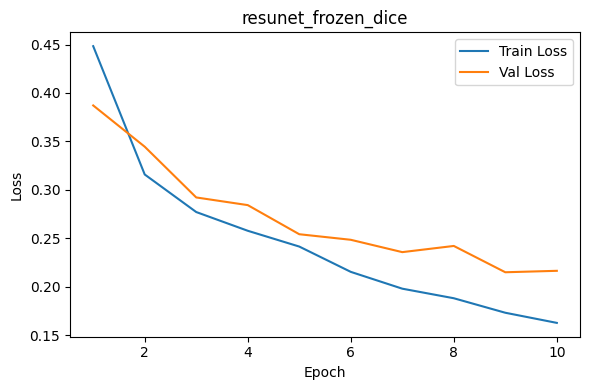

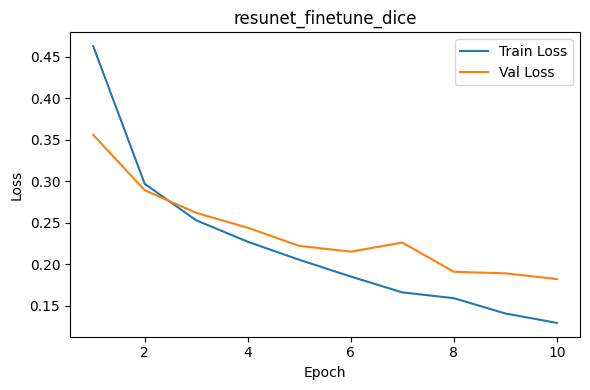

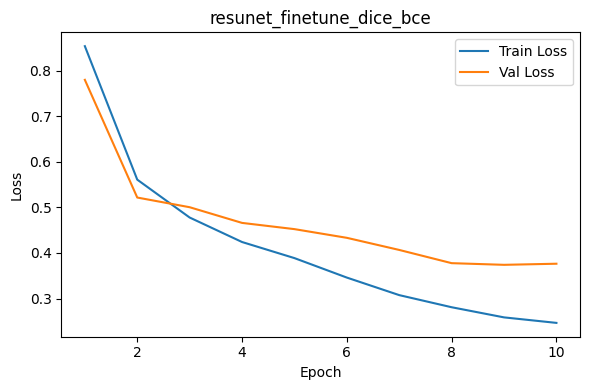

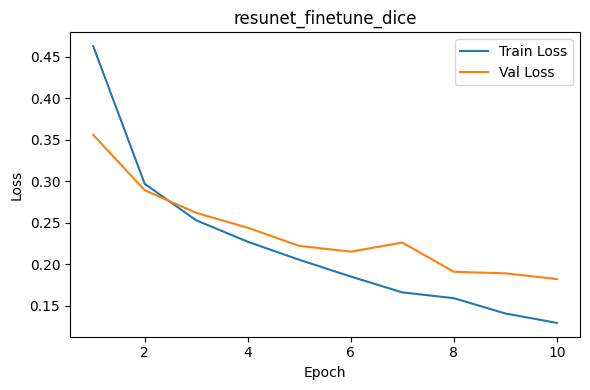

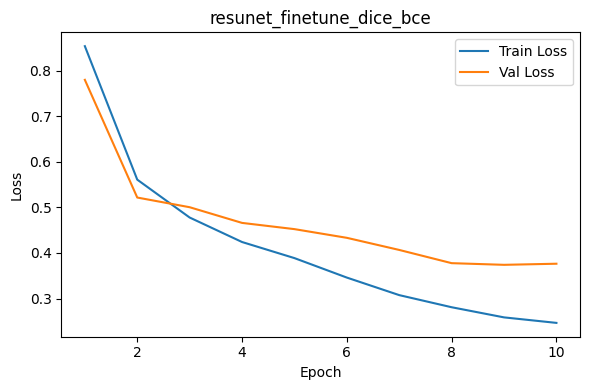

In [63]:
def plot_histories(history_dict):
    for name, df in history_dict.items():
        plt.figure(figsize=(6, 4))
        plt.plot(df["epoch"], df["train_loss"], label="Train Loss")
        plt.plot(df["epoch"], df["val_loss"], label="Val Loss")
        plt.xlabel("Epoch")
        plt.ylabel("Loss")
        plt.title(name)
        plt.legend()
        plt.tight_layout()
        plt.show()

plot_histories(all_histories)
plot_histories(loss_histories)

## 24. Show saved prediction examples

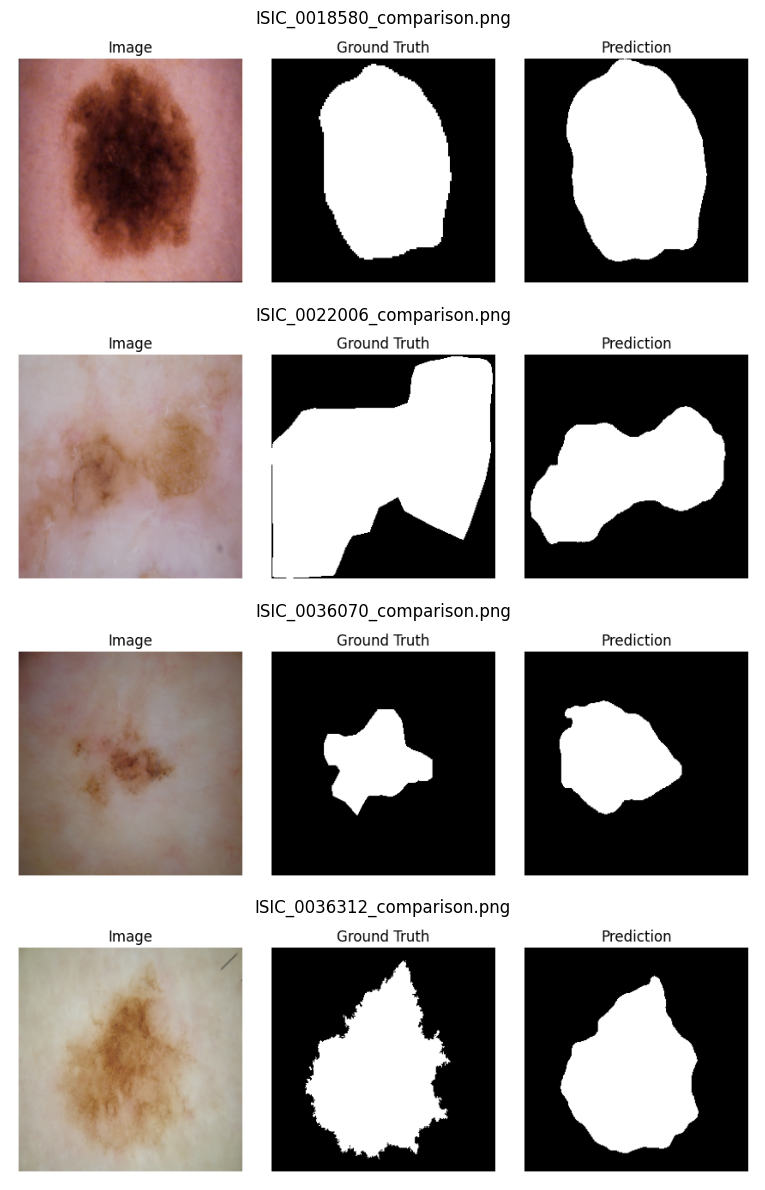

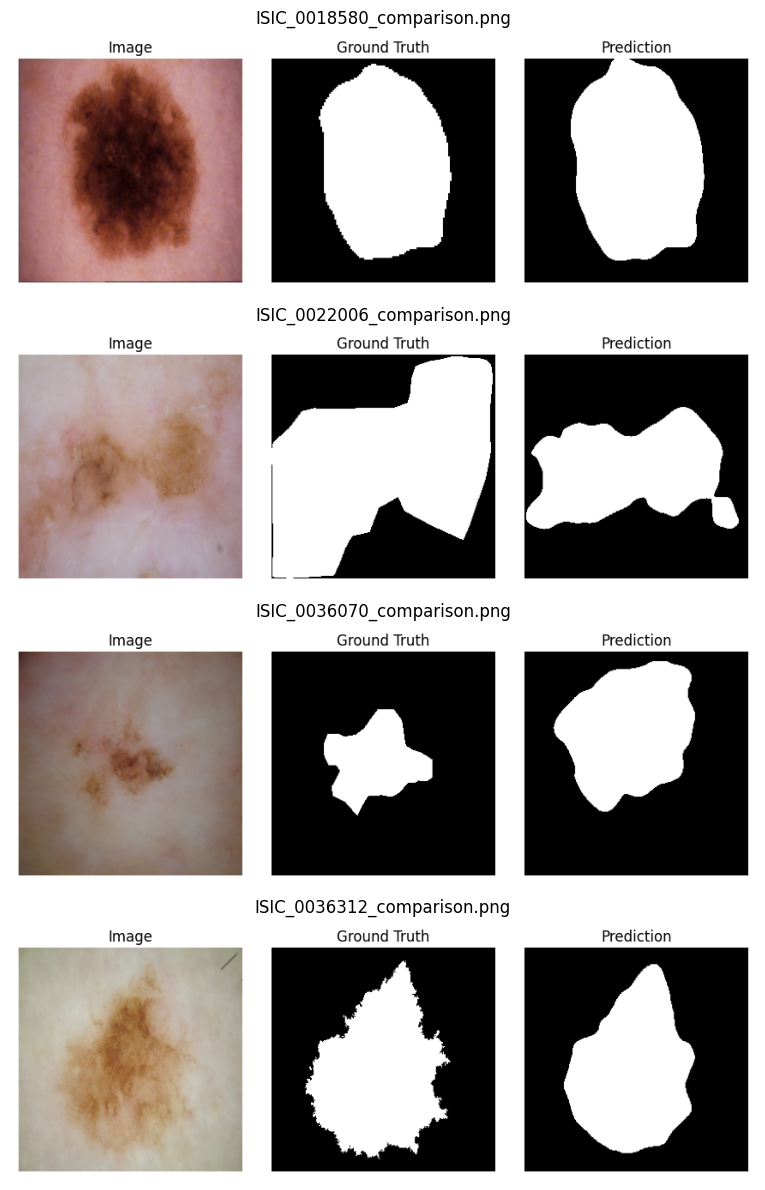

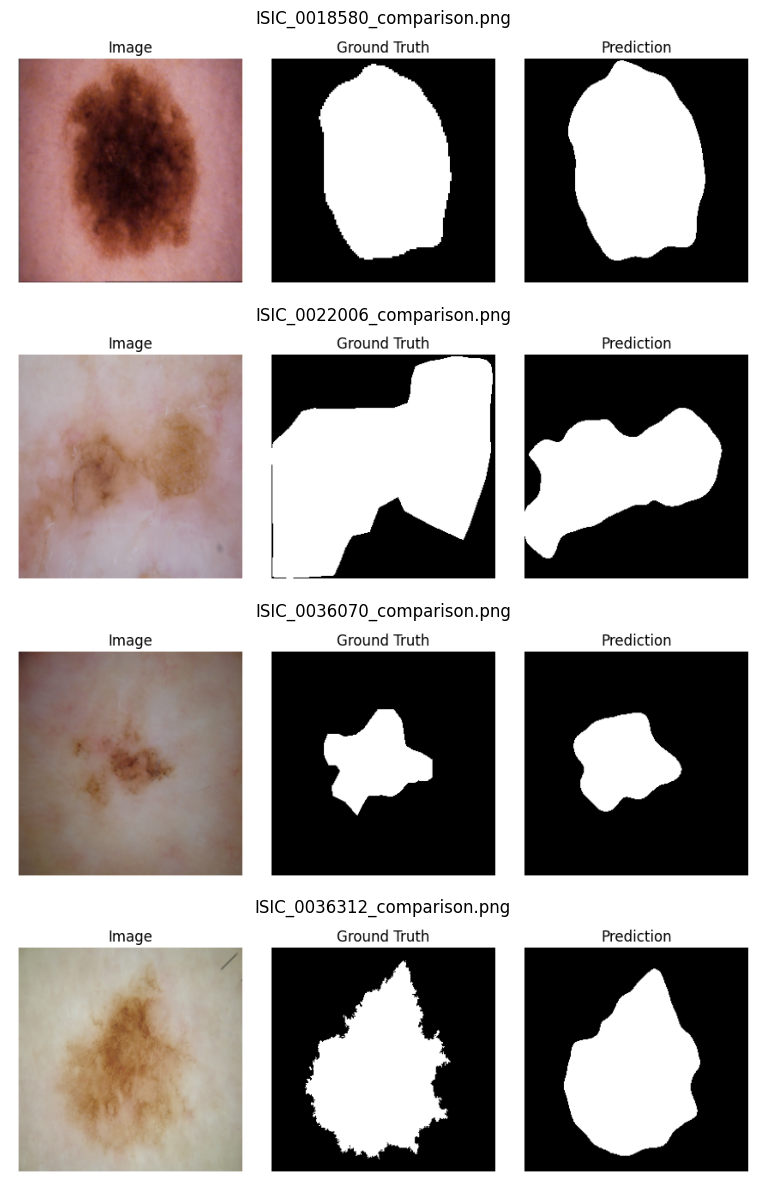

In [64]:
def show_saved_predictions(output_dir: str, experiment_name: str, max_items: int = 4):
    pred_dir = Path(output_dir) / experiment_name / "predictions"
    files = sorted(pred_dir.glob("*.png"))[:max_items]
    if not files:
        print("No saved predictions found for", experiment_name)
        return

    plt.figure(figsize=(10, 3 * len(files)))
    for i, file_path in enumerate(files, start=1):
        img = Image.open(file_path)
        plt.subplot(len(files), 1, i)
        plt.imshow(img)
        plt.axis("off")
        plt.title(file_path.name)
    plt.tight_layout()
    plt.show()

for experiment_name in ["unet_scratch_dice", "resunet_frozen_dice", "resunet_finetune_dice"]:
    show_saved_predictions(cfg.output_dir, experiment_name, max_items=cfg.num_visualizations)

## 25. Notes

Keep your notebook output organized and report the settings you used.

## 26. Saved outputs

Save the required tables and prediction figures.